In [45]:
# %% Imports
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import windows
import os
import cupy as cp
%matplotlib widget


In [46]:
# ---------- Inputs ----------
v_final = 0.150    # m/s
a_max   = 5.0      # m/s^2
# ----------------------------



print(f"t_accel = {v_final/a_max*1000} ms")

t_accel = 30.0 ms


In [47]:
data_dir = Path("~/eedm_jml/daqAnalysisAndExperiments/launch/measureTrackVelocityBeatNote/data_gitignore").expanduser()
files = sorted(data_dir.glob("*.npz"))

if len(files) == 1:
    fname = files[0]
    print(f"One file found, using: {fname.name}")
elif len(files) == 0:
    raise FileNotFoundError(f"No .npz files in {data_dir}")
else:
    most_recent = max(files, key=lambda p: p.stat().st_mtime)
    print(f"{len(files)} files found. Most recent: {most_recent.name}")
    user_in = input("Enter filename (blank = most recent): ").strip()
    fname = data_dir / user_in if user_in else most_recent
    print(f"Using: {fname.name}")

d = np.load(fname, allow_pickle=True)
print("Keys:", list(d.keys()))

t = d["times"]
v = d["voltages"]
fs = float(d["sample_rate"])
xinc = 1.0 / fs

print(f"N = {len(v)},  fs = {fs/1e6:.1f} MSa/s,  duration = {len(v)*xinc*1e3:.2f} ms")
print(f"V range: {v.min()*1e3:.2f} to {v.max()*1e3:.2f} mV")

106 files found. Most recent: beat_20260515_180423.npz
Using: beat_20260515_180423.npz
Keys: ['times', 'voltages', 'sample_rate', 'timestamp']
N = 10000000,  fs = 10.0 MSa/s,  duration = 1000.00 ms
V range: -31.75 to 2.56 mV


Cut: 50.000 to 250.000 ms (1999999 pts, 200.00 ms)


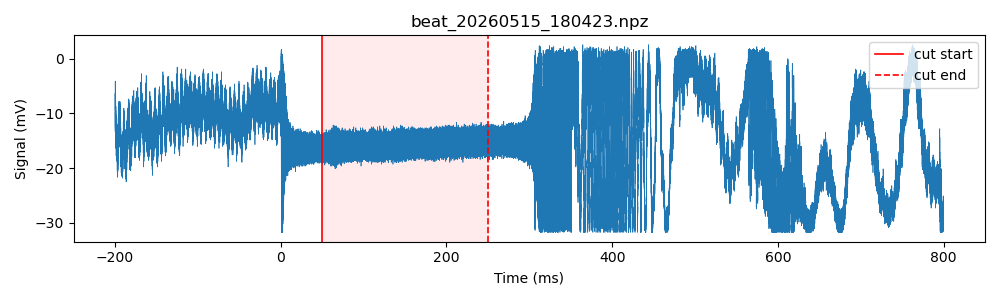

In [48]:
t_start = 50e-3      # seconds  <-- edit
t_end   = 250e-3    # seconds  <-- edit

# Clip to available range
t_start = max(t_start, t[0])
t_end   = min(t_end, t[-1])

i_start = np.searchsorted(t, t_start)
i_end   = np.searchsorted(t, t_end)
t_cut = t[i_start:i_end]
v_cut = v[i_start:i_end]
print(f"Cut: {t_start*1e3:.3f} to {t_end*1e3:.3f} ms ({len(v_cut)} pts, {len(v_cut)*xinc*1e3:.2f} ms)")

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t * 1e3, v * 1e3, lw=0.5)
ax.axvline(t_start * 1e3, color="r", lw=1.2, label="cut start")
ax.axvline(t_end   * 1e3, color="r", lw=1.2, ls="--", label="cut end")
ax.axvspan(t_start * 1e3, t_end * 1e3, color="r", alpha=0.08)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Signal (mV)")
ax.set_title(fname.name)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

Waterfall: 199 segments x 5001 freq bins
Segment duration: 1.000 ms,  freq resolution: 1000.0 Hz


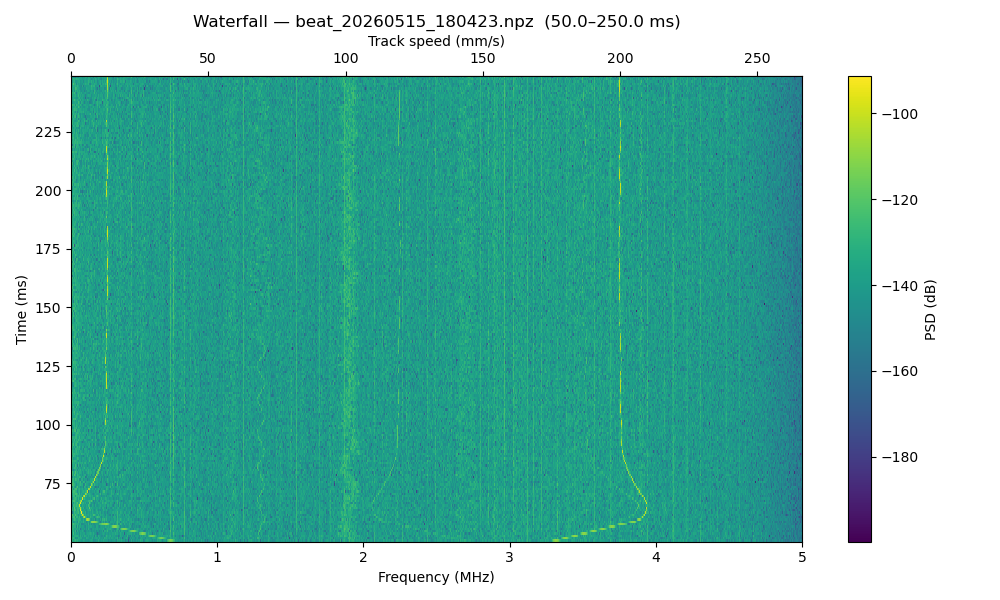

In [53]:
# %% Cell 3 — Waterfall on the cut data
seg_dur = 1e-3
overlap = 0
window_name = "hann"

nperseg = int(round(seg_dur / xinc))
nstep = int(round(nperseg * (1 - overlap)))
nseg = 1 + (len(v_cut) - nperseg) // nstep

if nseg < 1:
    raise ValueError(f"Cut region ({len(v_cut)*xinc*1e3:.2f} ms) shorter than segment ({seg_dur*1e3:.2f} ms)")

win = windows.get_window(window_name, nperseg)
win_norm = np.sum(win**2)

freqs = np.fft.rfftfreq(nperseg, d=xinc)
seg_times = t_cut[0] + (np.arange(nseg) * nstep + nperseg / 2) * xinc

spec = np.empty((nseg, len(freqs)), dtype=np.float32)
for i in range(nseg):
    chunk = v_cut[i*nstep : i*nstep + nperseg]
    chunk = (chunk - chunk.mean()) * win
    X = np.fft.rfft(chunk)
    psd = (np.abs(X)**2) / (fs * win_norm)
    psd[1:-1] *= 2
    spec[i] = psd

spec_db = 10 * np.log10(spec + 1e-20)
print(f"Waterfall: {nseg} segments x {len(freqs)} freq bins")
print(f"Segment duration: {seg_dur*1e3:.3f} ms,  freq resolution: {1/seg_dur:.1f} Hz")

WAVELENGTH = 852e-9   # m
N_BOUNCES  = 16       # factor (8 bounces, double-pass = 16)

def f_to_v(f_hz):
    return WAVELENGTH * f_hz / N_BOUNCES   # m/s

def v_to_f(v_ms):
    return N_BOUNCES * v_ms / WAVELENGTH   # Hz

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(
    freqs / 1e6,
    seg_times * 1e3,
    spec_db,
    shading="auto",
    cmap="viridis",
)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Time (ms)")
ax.set_title(f"Waterfall — {fname.name}  ({t_start*1e3:.1f}–{t_end*1e3:.1f} ms)")
fig.colorbar(im, ax=ax, label="PSD (dB)")

# Secondary x-axis: velocity in mm/s
# kHz -> mm/s:  v_mm = (852e-9 / 16) * (f_khz * 1e3) * 1e3 = 53.25e-3 * f_khz
secax = ax.secondary_xaxis(
    "top",
    functions=(
        lambda f_khz: f_to_v(f_khz * 1e3) * 1e6,   # kHz -> mm/s
        lambda v_mm:  v_to_f(v_mm * 1e-3) / 1e3,   # mm/s -> kHz
    ),
)
secax.set_xlabel("Track speed (mm/s)")

# Optional zoom / clim
# ax.set_xlim(0, 100)
# im.set_clim(vmax=spec_db.max(), vmin=spec_db.max() - 60)

plt.tight_layout()
plt.show()

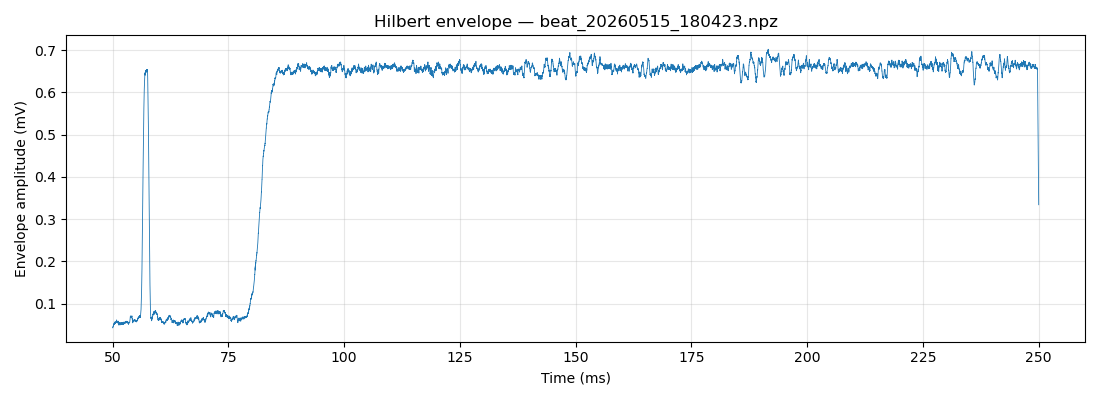

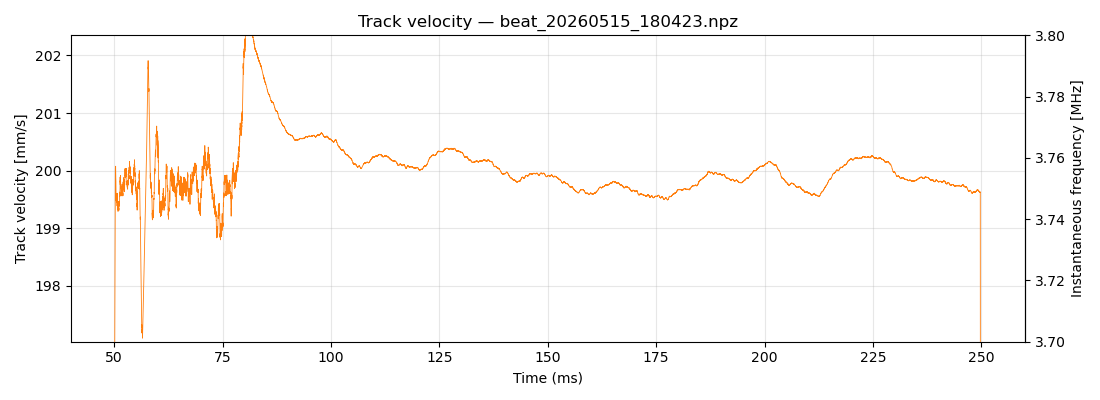

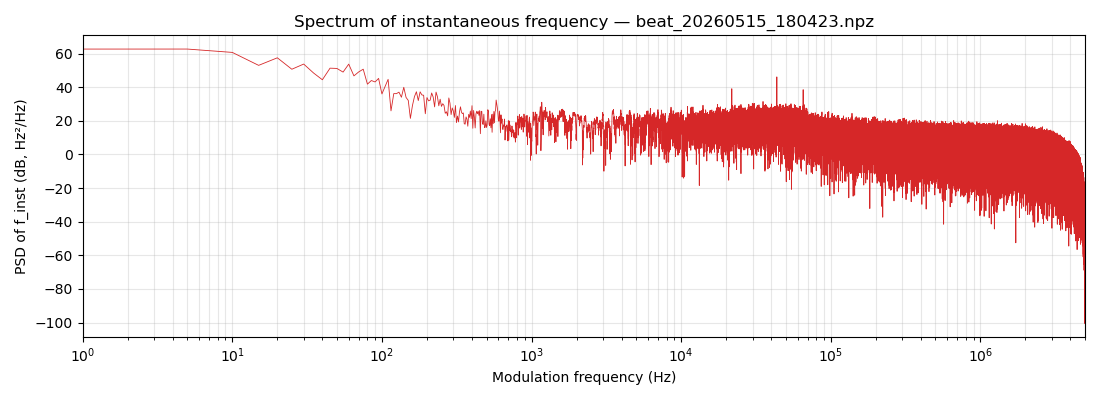

In [52]:
# %% Cell 4 — Hilbert envelope, instantaneous frequency, velocity
from scipy.signal import hilbert, butter, filtfilt
from scipy.ndimage import uniform_filter1d

# ---- Bandpass around the expected beat band ----
# Your signal lives roughly 0–4 MHz. Pick a band that excludes DC and the
# 2nd-harmonic ghost above ~3.6 MHz. Adjust as needed.
F_LO = 3.7e6      # Hz, high-pass corner (kills DC drift / low-freq junk)
F_HI = 3.8e6     # Hz, low-pass corner (kills the 4 MHz ghost)
ORDER = 4

nyq = fs / 2
b, a = butter(ORDER, [F_LO/nyq, F_HI/nyq], btype="band")
v_filt = filtfilt(b, a, v_cut)

# ---- Analytic signal ----
analytic = hilbert(v_filt)
envelope = np.abs(analytic)
phase = np.unwrap(np.angle(analytic))

# Instantaneous frequency via centered difference
f_inst = np.gradient(phase, xinc) / (2 * np.pi)   # Hz

# Optional: smooth f_inst a bit (rolling mean) to suppress phase noise.
# Window of ~1 ms is usually a good starting point.
SMOOTH_MS = 0.5
nsmooth = max(1, int(round(SMOOTH_MS * 1e-3 * fs)))
if nsmooth > 1:
    kernel = np.ones(nsmooth) / nsmooth
    f_inst_s = uniform_filter1d(f_inst, size=nsmooth, mode="nearest")
    env_s    = uniform_filter1d(envelope, size=nsmooth, mode="nearest")
else:
    f_inst_s = f_inst
    env_s    = envelope

# ---- Velocity ----
v_track = WAVELENGTH * f_inst_s / N_BOUNCES   # m/s

# Decimate for plotting (don't try to draw 10M points)
DECIM = max(1, len(t_cut) // 100000)
ts = t_cut[::DECIM] * 1e3   # ms

# %% Figure 1 — Hilbert envelope
plt.close('all')
fig1, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(ts, env_s[::DECIM] * 1e3, lw=0.6, color="C0")
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Envelope amplitude (mV)")
ax1.set_title(f"Hilbert envelope — {fname.name}")
ax1.grid(True, alpha=0.3)
fig1.tight_layout()
plt.show()


fig2, ax2 = plt.subplots(figsize=(11, 4))
v_track_khz = f_to_v(f_inst_s) * 1e3   # m/s -> mm/s
ax2.plot(ts, v_track_khz[::DECIM], lw=0.6, color="C1")
ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("Track velocity [mm/s]")
ax2.set_title(f"Track velocity — {fname.name}")
ax2.grid(True, alpha=0.3)
ax2.set_ylim(f_to_v(F_LO) * 1e3, f_to_v(F_HI) * 1e3)



secax = ax2.secondary_yaxis(
    "right",
    functions=(
        lambda v_mm:  v_to_f(v_mm * 1e-3) / 1e6,   # mm/s -> MHz
        lambda f_mhz: f_to_v(f_mhz * 1e6) * 1e3,   # MHz -> mm/s
    ),
)
secax.set_ylabel("Instantaneous frequency [MHz]")

fig2.tight_layout()
plt.show()


# %% Figure 4 — FFT of instantaneous frequency
# Reveals periodic structure in the velocity (mechanical resonances,
# servo oscillations, mains pickup, encoder ripple, etc.)

# Use the unsmoothed f_inst so we don't roll off real high-frequency content.
# Detrend by removing the mean (and optionally a linear trend) so the DC
# component and the overall sweep don't dominate the spectrum.
from scipy.signal import detrend

f_for_fft = detrend(f_inst, type="linear")   # remove mean + linear sweep

# Window to control spectral leakage
N = len(f_for_fft)
win = np.hanning(N)
win_norm = np.sum(win**2)

F = np.fft.rfft(f_for_fft * win)
psd = (np.abs(F) ** 2) / (fs * win_norm)
psd[1:-1] *= 2
freqs_fft = np.fft.rfftfreq(N, d=xinc)

psd_db = 10 * np.log10(psd + 1e-30)

fig4, ax4 = plt.subplots(figsize=(11, 4))
ax4.semilogx(freqs_fft, psd_db, lw=0.6, color="C3")
ax4.set_xlabel("Modulation frequency (Hz)")
ax4.set_ylabel("PSD of f_inst (dB, Hz²/Hz)")
ax4.set_title(f"Spectrum of instantaneous frequency — {fname.name}")
ax4.grid(True, which="both", alpha=0.3)
ax4.set_xlim(1, fs/2)
fig4.tight_layout()
plt.show()